In [1]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys # Add the module path. Windows and Linux use different path separators; the raw string prevents escape sequences such as \n from being interpreted.
sys.path.insert(0, r"../main_code/3d")
for _mod in ['generate_data', 'mesh', 'adaptive_int', 'visual', 'matrix_assemble', 'inverse_solver', 'mea_3d', 'net_3d', 'source_eval', 'error_general_3d', 'main', 'bound_detect', 'q_filter']:
    sys.modules.pop(_mod, None)
import generate_data,mesh,adaptive_int,visual,matrix_assemble,inverse_solver,mea_3d,net_3d,source_eval,error_general_3d,main
CUDA_LAUNCH_BLOCKING=2

def ana_S(x, center,R, r, S0):
    x1=x[:,0]
    x2=x[:,1]
    x3=x[:,2]
    cx, cy, cz = center[0,0],center[0,1],center[0,2]
    
    # Compute whether each point lies inside the torus relative to the shifted center.
    
    x_rel, y_rel, z_rel = x1 - cx, x2 - cy, x3 - cz
    condition = (np.sqrt(x_rel**2 + y_rel**2) - R)**2 + z_rel**2 <= r**2
    
    # Use np.where to return S0 or 0 according to the condition.
    return np.where(condition, S0, 0.0)

cuda:3


In [2]:
import copy
Nx,Ny,Nz=1,1,1
Ix,Iy,Iz=4,4,4  # Number of grid cells in the x direction
nx,ny,nz=3,3,3  # Gauss points per cell in the x direction
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81]
R_true = 0.25            # Major radius R
r_true = 0.15            # Minor radius r
S0= 1.0  
tau_x_min,tau_x_max,tau_y_min,tau_y_max,tau_z_min,tau_z_max=-0.5,0.5,-0.5,0.5,-0.5,0.5
b_x_min,b_x_max,b_y_min,b_y_max,b_z_min,b_z_max=-0.75,0.75,-0.75,0.75,-0.75,0.75 # On boundary Gamma
num_batches_gauss=1
b_n=10
points_b=mea_3d.generate_cube_surface(b_x_min,b_x_max,b_y_min,b_y_max,b_z_min,b_z_max,b_n) # Collect data on boundary Gamma
center_true=np.array([[0.0,0.0,0.0]])
number_gene=50
eps=0.05
batch_number_rec_mea,mea=2,1
cupy_device = device.index if device.type == "cuda" else 0
num_batches_gauss=4
num_batches_appr=10
num_batches_mea=1

In [3]:
F_diri_5=np.load("./noise=5%/F_diri_5%.npy")


In [4]:
M=3600
af="Tanh"   # Initial activation setting
R_m=20
models0 = net_3d.local_rep(in_features=3, out_features=1, hidden_layers=1, M=M, x_max=tau_x_min, x_min=tau_x_max, y_max=tau_y_max, y_min=tau_y_min,z_min=tau_z_min,z_max=tau_z_max, r_min=[], r_max=[],R_min=[],R_max=[],b1_min=[],b1_max=[],b2_min=[],b2_max=[],b3_min=[],b3_max=[],K_min=[],K_max=[],R_m_for_init=R_m,af=af,Shape=[],device=device).to(device)

Plotting 64 cells. Levels: 0 to 0


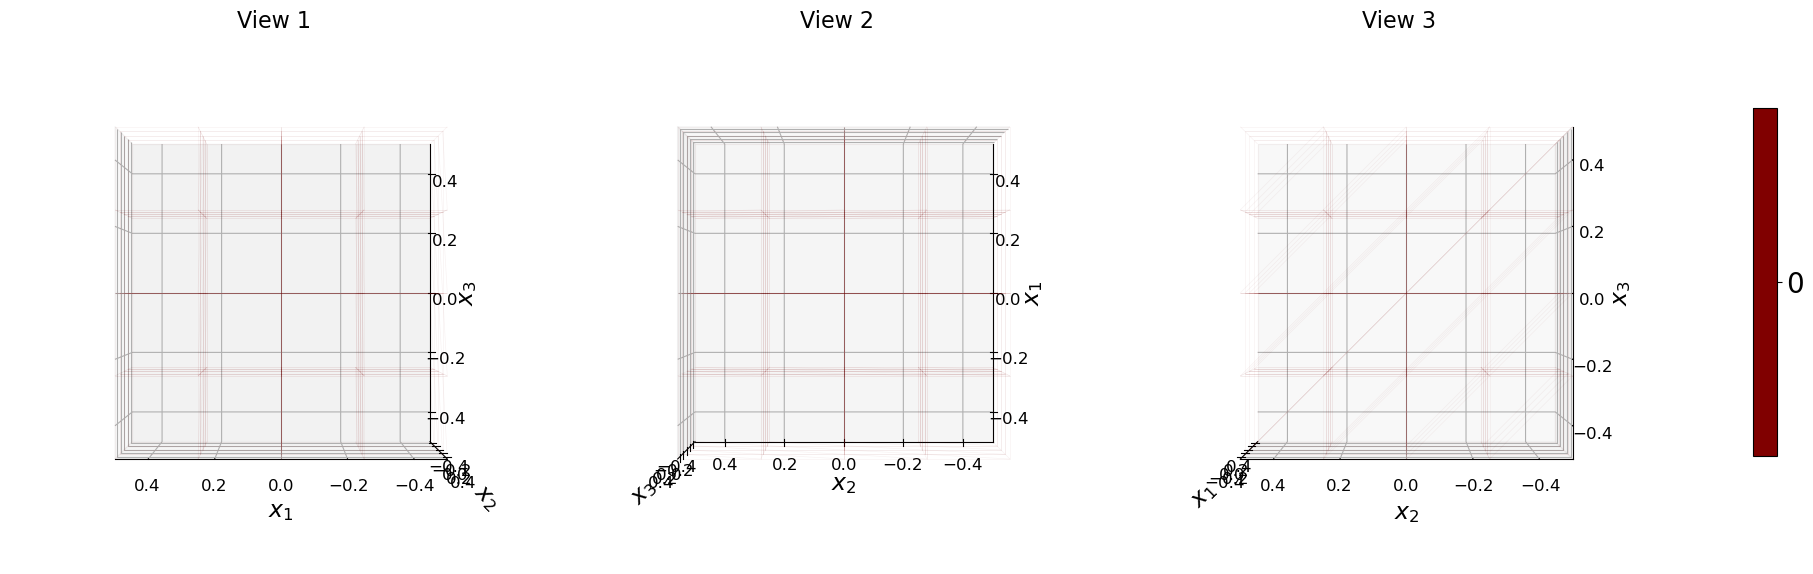

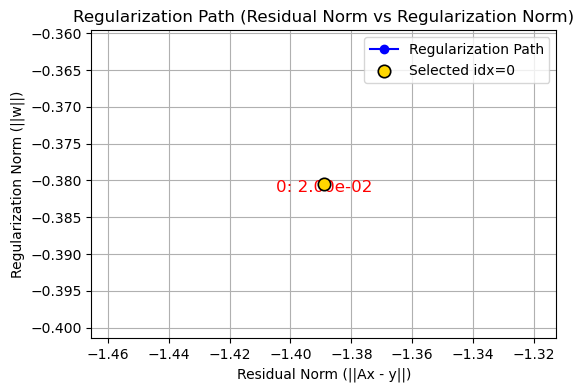

Training error at iteration 0 :
S_l_inf= 1.9032237706898187 S_L_2= 0.147663932690329 S_l_2= 0.40299745852693897
Generalization error at iteration 0 :
S_l_inf= 2.3523016342338905 S_L_2= 0.14152865946134355 S_l_2= 0.43250924052030076


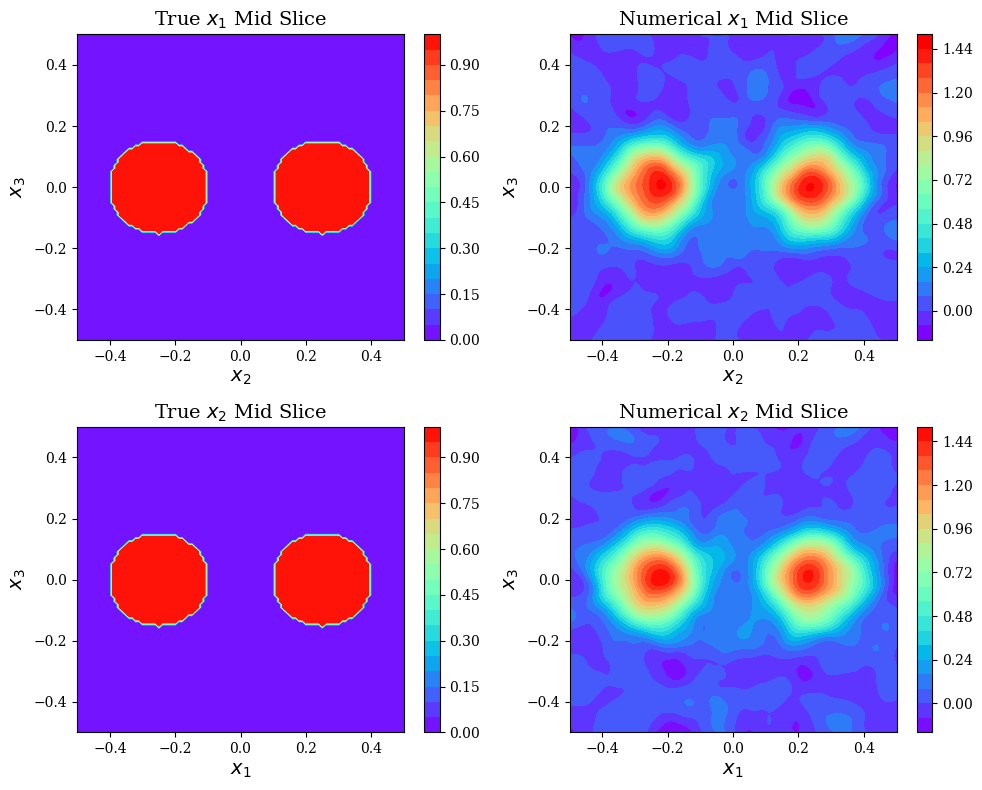

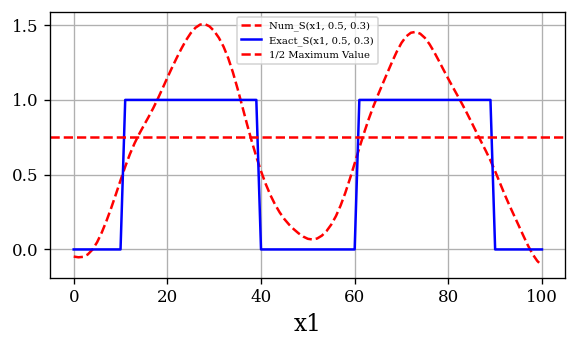

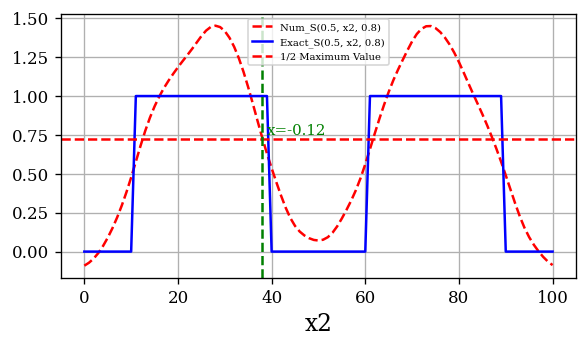

Current number of cells: 512
Plotting 512 cells. Levels: 1 to 1


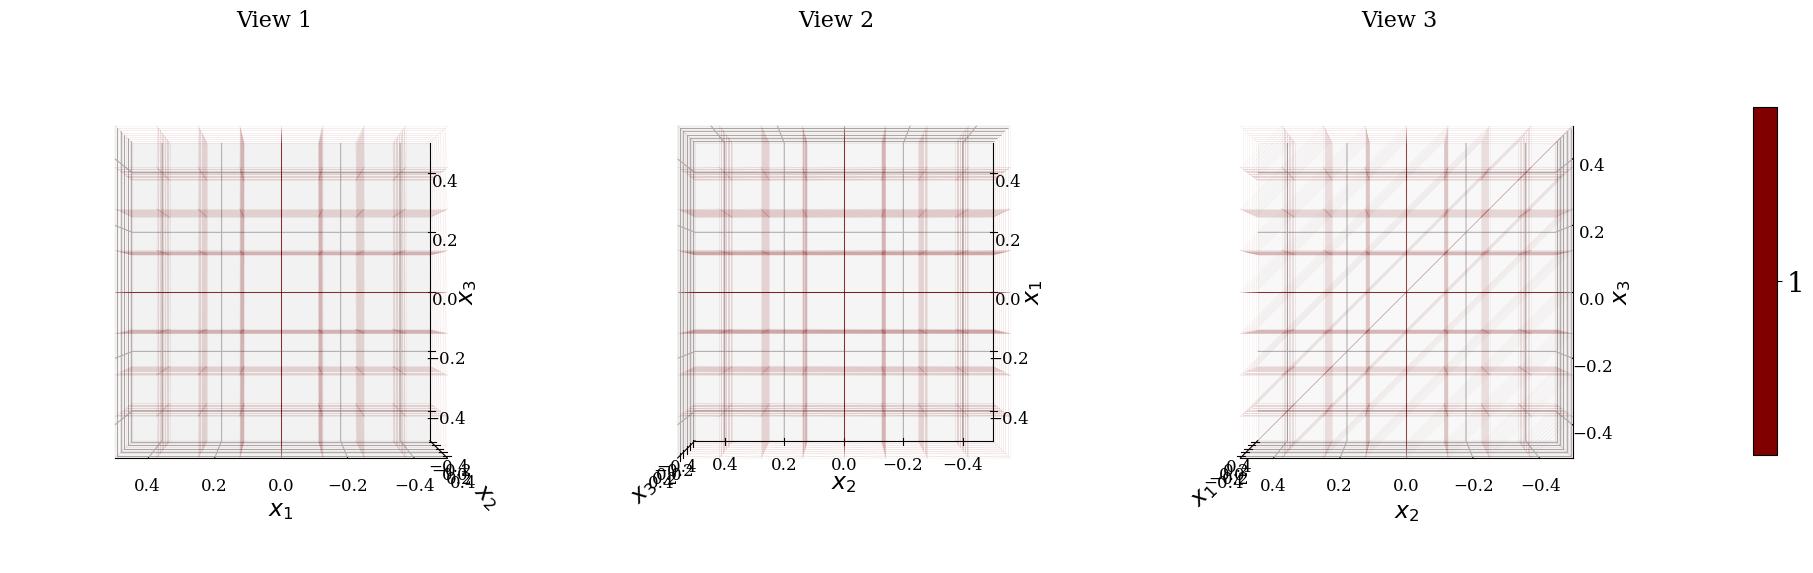

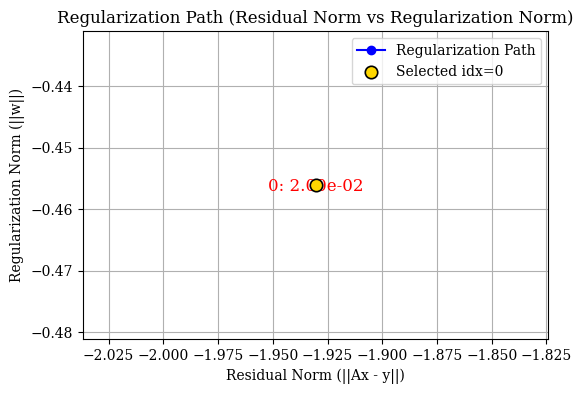

Training error at iteration 1 :
S_l_inf= 1.742397010394461 S_L_2= 0.12287951688861413 S_l_2= 0.3630101506713507
Generalization error at iteration 1 :
S_l_inf= 2.026531778811627 S_L_2= 0.11953616355047689 S_l_2= 0.3653005370693025


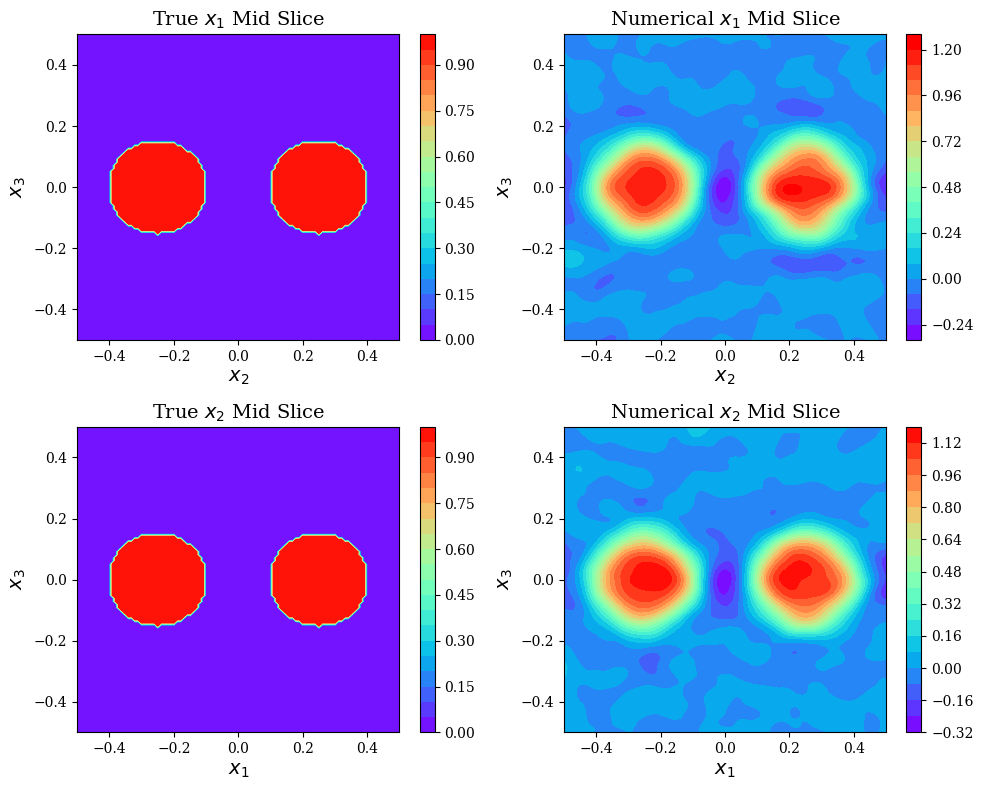

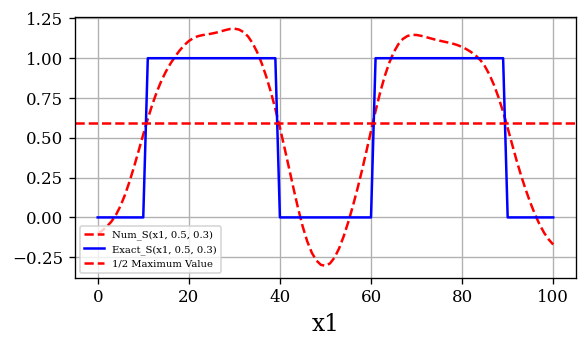

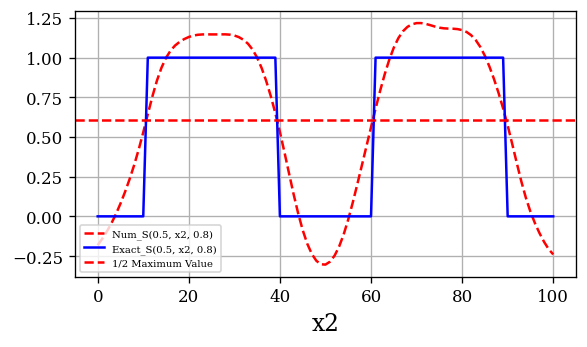

Current number of cells: 1408
Plotting 1408 cells. Levels: 1 to 2


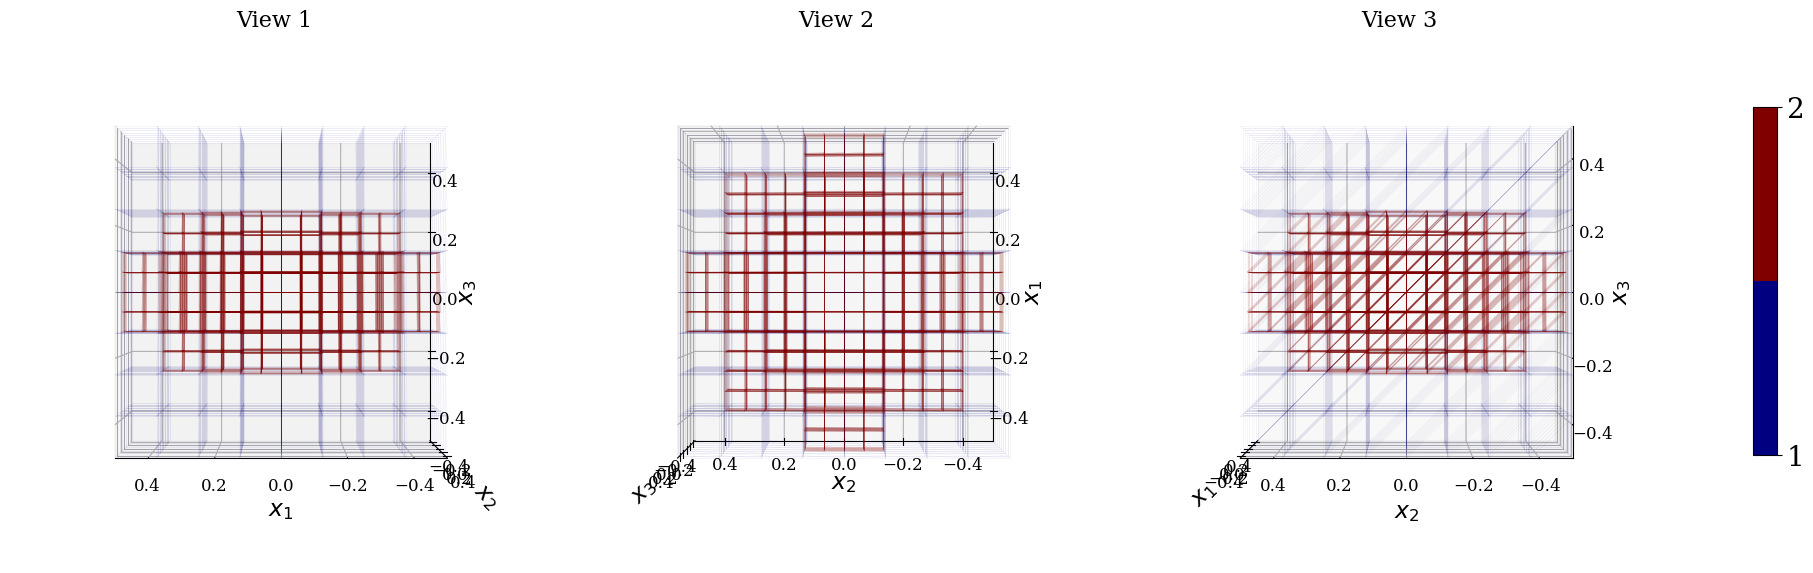

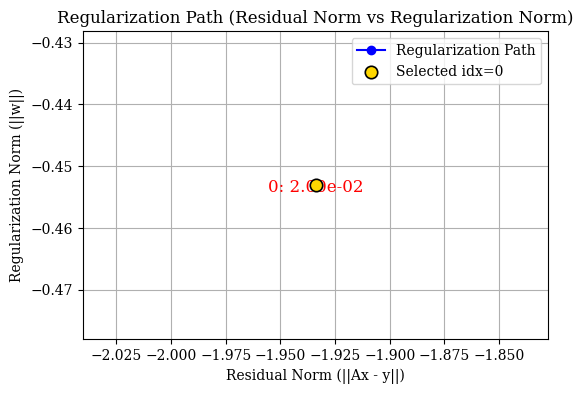

Training error at iteration 2 :
S_l_inf= 1.1730577395152135 S_L_2= 0.19492605114633724 S_l_2= 0.34352819337493856
Generalization error at iteration 2 :
S_l_inf= 2.041014203338787 S_L_2= 0.11923732749654171 S_l_2= 0.3643872990352569


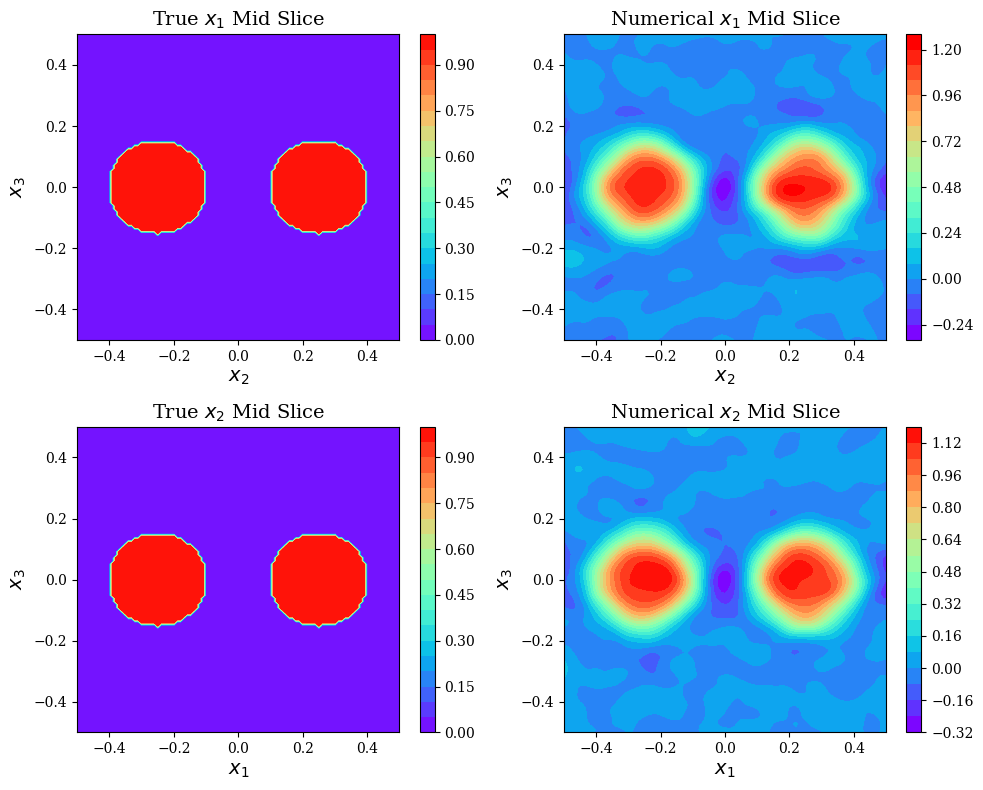

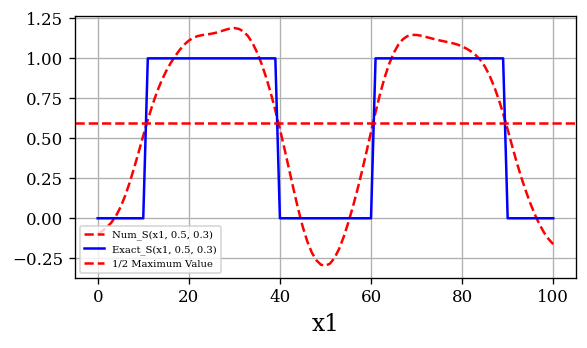

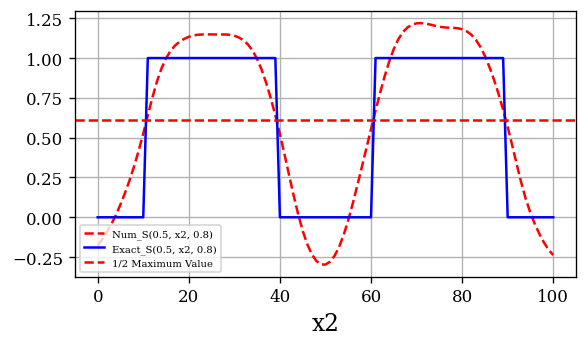

Current number of cells: 1408


In [5]:
Ix,Iy,Iz=4,4,4  # Number of grid cells in the x direction
nx,ny,nz=3,3,3  # Gauss points per cell in the x direction
ratio1=[0.5,0.5,0.5]
cells= mesh.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,tau_z_min,tau_z_max,Ix,nx,points_b) # Create the initial grid
initial_cells=copy.deepcopy(cells) # Make a copy
delta=10**(-3)

lamb_regu=2*np.logspace(-2,-1,1)
Qx,Qy,Qz=50,50,50
iter_int=3
max_level=4
current_maxiter=1
refine_threshold_S = 1/100
refine_threshold_grad = 1/300
condition="Dirichlet"
cells_store,refinement_stats_store,w_,point_number,g_store,g_S,S_num_store,S_l2,S_basis_store=main.ada_int(iter_int,delta,cells,nx,models0,M,af,kk,F_diri_5,tau_x_min,tau_x_max,tau_y_min,tau_y_max,tau_z_min,tau_z_max,center_true,R_true,r_true,S0,ana_S,points_b,lamb_regu,Qx,Qy,Qz,ratio1,condition,device,cupy_device,refine_threshold_S,refine_threshold_grad,current_maxiter,max_level)

In [6]:
import pickle
output_pickle_file = "./noise=5%/cells_store.pkl"
with open(output_pickle_file, 'wb') as f: # 'wb' for write binary
    pickle.dump(cells_store,f)

In [23]:
np.save("./noise=5%/S_basis_store.npy",S_basis_store[-1])
np.save("./noise=5%/g_S.npy",g_S)

NameError: name 'S_basis_store' is not defined

In [5]:
g_S=np.load("./noise=5%/g_S.npy")
S_num_store=np.load("./noise=5%/S_num_store.npy",allow_pickle=True)
S_basis=np.load("./noise=5%/S_basis_store.npy",allow_pickle=True)
import pickle 
with open("./noise=5%/cells_store.pkl", 'rb') as f: # 'rb' for read binary
    cells_store = pickle.load(f)

Grid shape from g_S: 101x101x101
DBSCAN eps = 0.050000 (5.000000 * h, h = 0.010000)
Number of detected clusters: 1
  CV of S_num: 0.265
Cluster 0: AR=2.48
  Res_Rect=0.249800 vs Res_Ellip=0.195514 vs Res_Tori=0.033219
  center=(-0.0001, -0.0027, 0.0015)
  Lx=0.820000, Ly=0.820000, Lz=0.330000
  dist_01=0.109477, dist_99=0.403401
  R_inner=0.104601, R_outer=0.402475
  R_major=0.253538, r_minor=0.148937
  torus_axis=2, torus_plane_dims=(0, 1)
  -> Decision: Donut (Sigmoid)


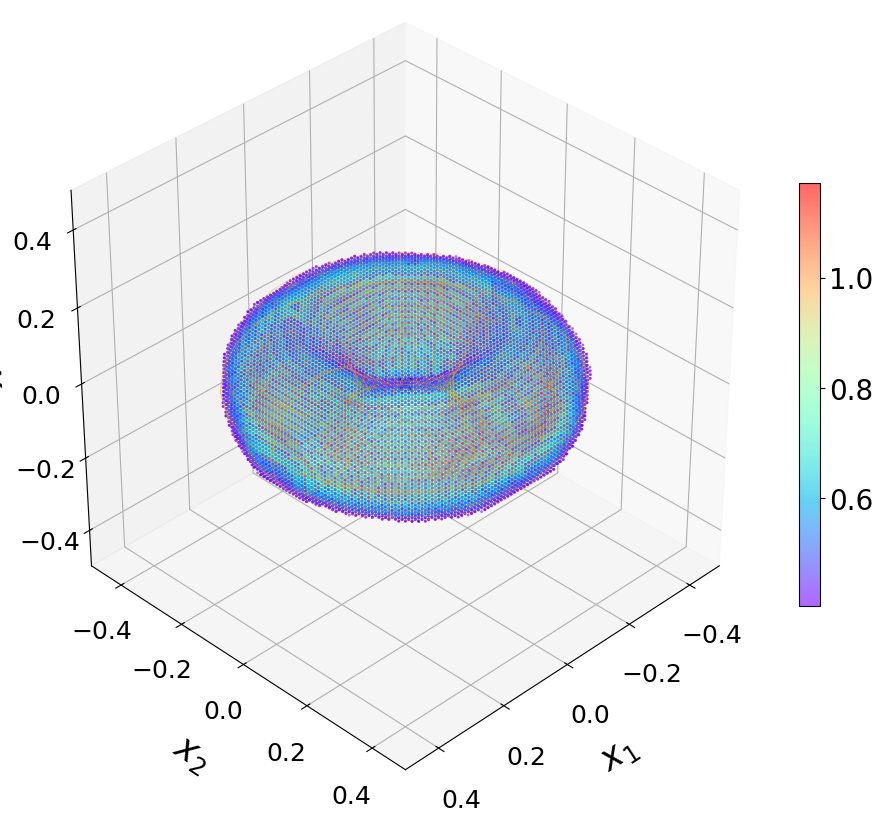

In [6]:
from importlib import reload
import bound_detect
reload(bound_detect)

# Dynamically get the shape of g_S to ensure dimension consistency
nx, ny, nz = g_S.shape
print(f"Grid shape from g_S: {nx}x{ny}x{nz}")

x = np.linspace(tau_x_min, tau_x_max, nx)
y = np.linspace(tau_y_min, tau_y_max, ny)
z = np.linspace(tau_z_min, tau_z_max, nz)

# Use indexing='ij' to match matrix indices (row, col, depth) -> (x, y, z)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

eps_cluster=5
mini_samples=20 
para_abs=3
para_grad=3
elev=35
azim=45
results = bound_detect.detect_shape_3d(
    g_S, X, Y, Z, 
    tau_x_min, tau_x_max, tau_y_min, tau_y_max, tau_z_min, tau_z_max,
    para_abs, para_grad, eps_cluster, mini_samples, 
    S_num_store[-1], elev=elev, azim=azim,
    output_directory="./noise=5%", 
    output_filename="plot_3d_top1.png"
)

Grid shape from g_S: 101x101x101
DBSCAN eps = 0.050000 (5.000000 * h, h = 0.010000)
Number of detected clusters: 1
  CV of S_num: 0.265
Cluster 0: AR=2.48
  Res_Rect=0.285355 vs Res_Ellip=0.170232 vs Res_Tori=0.040178
  center=(-0.0001, -0.0027, 0.0015)
  Lx=0.820000, Ly=0.820000, Lz=0.330000
  dist_01=0.109477, dist_99=0.403401
  R_inner=0.104601, R_outer=0.402475
  R_major=0.253538, r_minor=0.148937
  torus_axis=2, torus_plane_dims=(0, 1)
  -> Decision: Donut (Sigmoid)


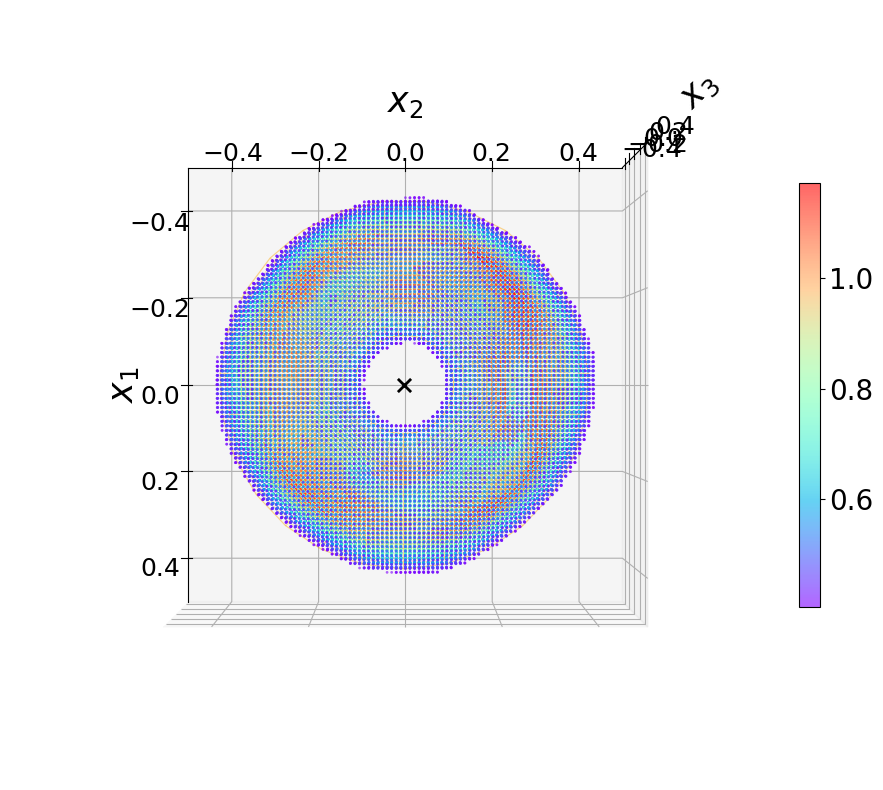

In [9]:
from importlib import reload
import bound_detect
reload(bound_detect)

# Dynamically get the shape of g_S to ensure dimension consistency
nx, ny, nz = g_S.shape
print(f"Grid shape from g_S: {nx}x{ny}x{nz}")

x = np.linspace(tau_x_min, tau_x_max, nx)
y = np.linspace(tau_y_min, tau_y_max, ny)
z = np.linspace(tau_z_min, tau_z_max, nz)

# Use indexing='ij' to match matrix indices (row, col, depth) -> (x, y, z)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

eps_cluster=5
mini_samples=20 
para_abs=3
para_grad=3
elev=90
azim=0
results = bound_detect.detect_shape_3d(
    g_S, X, Y, Z, 
    tau_x_min, tau_x_max, tau_y_min, tau_y_max, tau_z_min, tau_z_max,
    para_abs, para_grad, eps_cluster, mini_samples, 
    S_num_store[-1], elev=elev, azim=azim,
    output_directory="./noise=5%", 
    output_filename="plot_3d_top1.png"
)

Grid shape from g_S: 101x101x101
DBSCAN eps = 0.050000 (5.000000 * h, h = 0.010000)
Number of detected clusters: 1
  CV of S_num: 0.265
Cluster 0: AR=2.48
  Res_Rect=0.249800 vs Res_Ellip=0.195514 vs Res_Tori=0.033219
  center=(-0.0001, -0.0027, 0.0015)
  Lx=0.820000, Ly=0.820000, Lz=0.330000
  dist_01=0.109477, dist_99=0.403401
  R_inner=0.104601, R_outer=0.402475
  R_major=0.253538, r_minor=0.148937
  torus_axis=2, torus_plane_dims=(0, 1)
  -> Decision: Donut (Sigmoid)


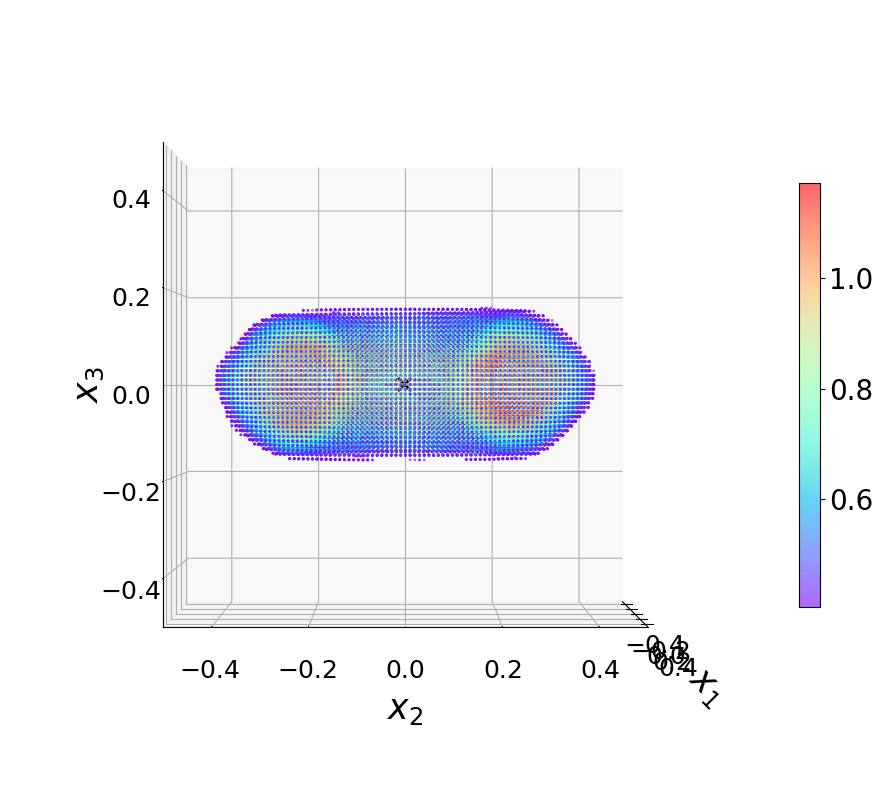

In [7]:
from importlib import reload
import bound_detect
reload(bound_detect)

# Dynamically get the shape of g_S to ensure dimension consistency
nx, ny, nz = g_S.shape
print(f"Grid shape from g_S: {nx}x{ny}x{nz}")

x = np.linspace(tau_x_min, tau_x_max, nx)
y = np.linspace(tau_y_min, tau_y_max, ny)
z = np.linspace(tau_z_min, tau_z_max, nz)

# Use indexing='ij' to match matrix indices (row, col, depth) -> (x, y, z)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

eps_cluster=5
mini_samples=20 
para_abs=3
para_grad=3
elev=0
azim=0
results = bound_detect.detect_shape_3d(
    g_S, X, Y, Z, 
    tau_x_min, tau_x_max, tau_y_min, tau_y_max, tau_z_min, tau_z_max,
    para_abs, para_grad, eps_cluster, mini_samples, 
    S_num_store[-1], elev=elev, azim=azim,
    output_directory="./noise=5%", 
    output_filename="plot_3d_top1.png"
)


In [9]:
reload(bound_detect)
bound_detect.print_latex_shape_detection_rows_3d(
    results,
    example_name='3-D "donut"',
    include_header=True,
)

LaTeX table rows:
{\emph{Ex}} & Cluster $k$ & $\boldsymbol{c}_k$ & $r_k$ or $\boldsymbol{L}_k$ & $\mathcal{E}_{\text{rect}}^{(k)}$ & $\mathcal{E}_{\text{ellip}}^{(k)}$ & $\mathcal{E}_{\text{tori}}^{(k)}$ & $\mathcal{T}_k$ & $\sigma_k$ \\
3-D "donut" & 1 & (-6.73e-05, -2.68e-03, 1.53e-03) & \begin{tabular}{@{}c@{}} 
$\mathbf{r_{\text{min}}=1.05e-01}$ \\
$\mathbf{r_{\text{max}}=4.02e-01}$
\end{tabular} & 0.250 & 0.196 & 0.033 & \emph{Tori} & Sigmoid \\


In [8]:
results

[{'cluster_id': 0,
  'shape': 'Donut',
  'params': {'center': array([-6.72640382e-05, -2.68422939e-03,  1.52855436e-03]),
   'R_inner': 0.10460097957705539,
   'R_outer': 0.40247488021696465,
   'R_major': 0.25353792989701,
   'r_minor': 0.14893695031995463,
   'r_min': 0.10460097957705539,
   'r_max': 0.40247488021696465,
   'r_inner': 0.14893695031995463,
   'r': 0.29787390063990926},
  'profile': 'Sigmoid',
  'boundary_points': array([[-0.4284, -0.0102, -0.0662],
         [-0.4284, -0.0102, -0.056 ],
         [-0.4284, -0.0102, -0.0458],
         ...,
         [ 0.4182,  0.0714, -0.0152],
         [ 0.4182,  0.0714, -0.005 ],
         [ 0.4182,  0.0714,  0.0052]]),
  'diagnostics': {'Lx': 0.8200000000000001,
   'Ly': 0.8200000000000001,
   'Lz': 0.33,
   'aspect_ratio': 2.484848484848485,
   'res_rect': 0.24980013861394715,
   'res_ellip': 0.19551357435246275,
   'res_tori': 0.03321908240880919,
   'res_tori_3d': 0.2266072214175466,
   'res_tori_projection': 0.03321908240880919,
   

In [10]:
center=results[0]['params']['center']
r_inner= results[0]['params']['r_inner']
R=results[0]['params']['R_outer']-r_inner

In [11]:
r_inner

0.14893695031995463

In [12]:
R

0.25353792989701

In [15]:
from importlib import reload
reload(net_3d)

<module 'net_3d' from '/data1/hxw-b25/MA-RFM/3D_donut/../main_code/3d/net_3d.py'>

In [13]:
M=1600
eps_r=0.05
eps_R=0.05
eps_c=0.05
r_min,r_max=(1-eps_r)*r_inner,(1+eps_r)*r_inner
R_min,R_max=(1-eps_R)*R,(1+eps_R)*R
b1_min,b1_max=-center[0]*(1+eps_c),center[0]*(1+eps_c)
b2_min,b2_max=center[1]*(1+eps_c),-center[1]*(1+eps_c)
b3_min,b3_max=-center[2]*(1+eps_c),center[2]*(1+eps_c)

K_min,K_max=2000,50000
condition="Dirichlet"
af="sigmoid"
Shape="sweet"
R_m=20
model_sigmoid=net_3d.local_rep(in_features=3, out_features=1, hidden_layers=1, M=M, x_min=tau_x_min, x_max=tau_x_max, y_min=tau_y_min, y_max=tau_y_max,z_min=tau_z_min,z_max=tau_z_max,r_min=r_min,r_max=r_max,R_min=R_min,R_max=R_max,b1_min=b1_min,b1_max=b1_max,b2_min=b2_min,b2_max=b2_max,b3_min=b3_min,b3_max=b3_max,K_min=K_min,K_max=K_max,R_m_for_init=R_m,af=af,Shape=Shape,device=device).to(device)

In [14]:
r_min,r_max,R_min,R_max,b1_min,b1_max,b2_min,b2_max,b3_min,b3_max,K_min,K_max


(0.14149010280395688,
 0.15638379783595238,
 0.2408610334021595,
 0.2662148263918605,
 np.float64(7.062724014337483e-05),
 np.float64(-7.062724014337483e-05),
 np.float64(-0.002818440860215044),
 np.float64(0.002818440860215044),
 np.float64(-0.001604982078853033),
 np.float64(0.001604982078853033),
 2000,
 50000)

In [18]:
len(cells_store[-1])

1408

In [19]:
sum_mat,all_g_p1,all_g_n,cells_copy1,S_basis=matrix_assemble.mat_assemble2(cells_store[-1],models0,model_sigmoid,[],S_basis,"mix",Shape,kk,0,points_b,condition,device,cupy_device)


In [20]:
sum_mat.shape

(25200, 5200)

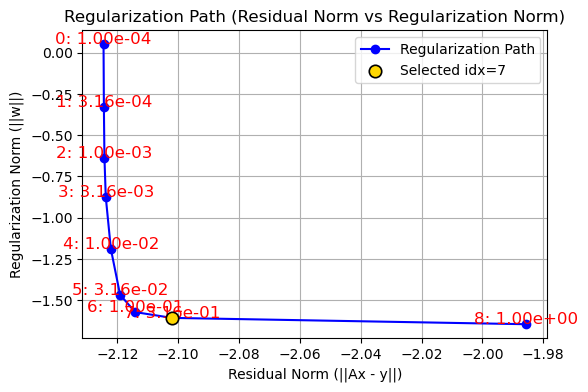

In [21]:
lamb_regu=np.logspace(-4,0,9,endpoint=True)
res,reg_norm,w_store=inverse_solver.L_curve(sum_mat,F_diri_5,lamb_regu,cupy_device) # Solve first

In [22]:
Qx,Qy,Qz=150,150,150
sample_s=error_general_3d.test_p(Qx,Qy,Qz,tau_x_min,tau_x_max,tau_y_min,tau_y_max,tau_z_min,tau_z_max)

In [23]:
# Load models0, model_sigmoid, and w_store
# models0=torch.load("./noise=5%/model_tanh_4*10**-4.pth", map_location=device)
# model_sigmoid=torch.load("./noise=5%/model_sigmoid_0.0009999999999999998.pth", map_location=device)
# w_store=np.load("./noise=5%/w_store.npy",allow_pickle=True)

L-curve corner index: 7
Curvature-centered lambda window:
  idx=6, lambda=1.000000e-01, curvature=3.425436e+00
  idx=7, lambda=3.162278e-01, curvature=4.181493e+00 <== center
  idx=8, lambda=1.000000e+00, curvature=0.000000e+00
candidate idx: [6 7 8]
candidate lambda: [0.1        0.31622777 1.        ]
S_l_inf= 1.8662248202740872 S_L_2= 0.05104978502330265 S_l_2= 0.15406324875949587


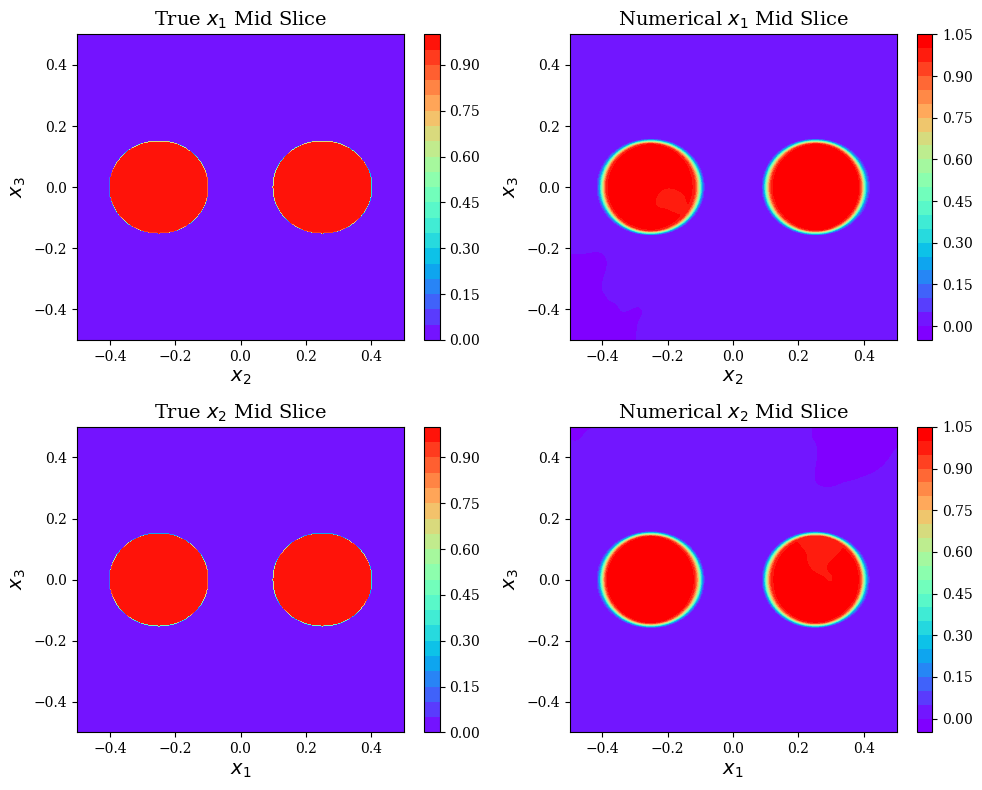

candidate idx=6, lamb=0.010000000000000002, S_l_inf=1.8662248202740872, S_l_2=0.15406324875949587
S_l_inf= 2.0668174593777526 S_L_2= 0.0545272821171355 S_l_2= 0.1645579942238115


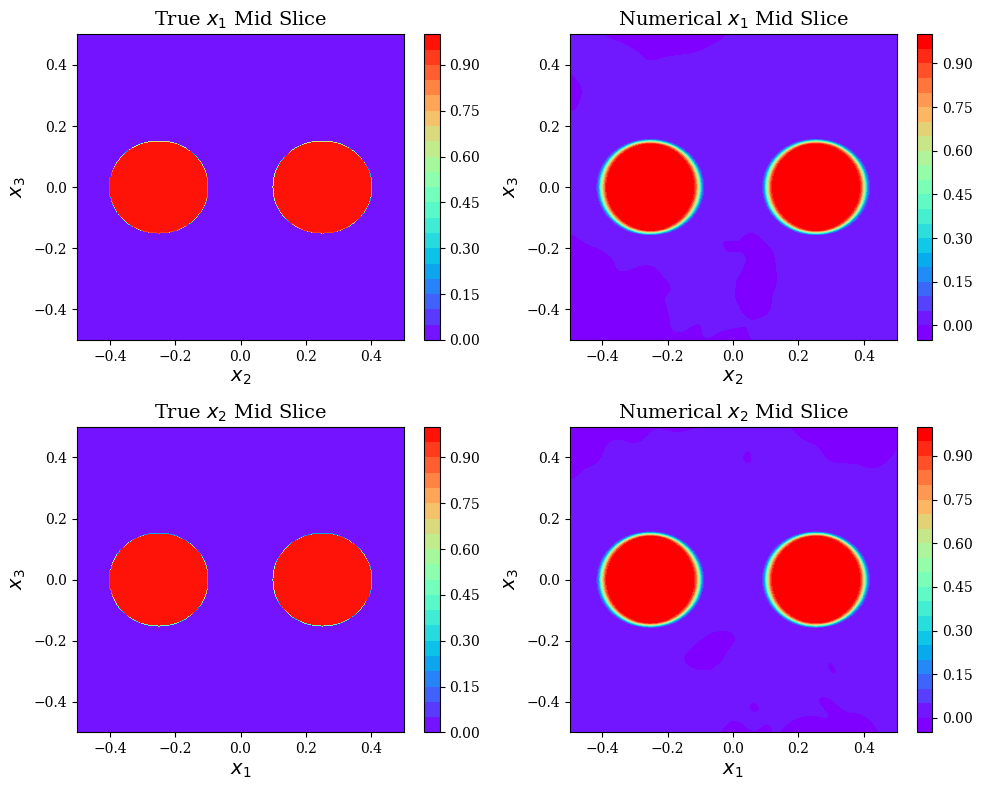

candidate idx=7, lamb=0.1, S_l_inf=2.0668174593777526, S_l_2=0.1645579942238115
S_l_inf= 2.191860119806547 S_L_2= 0.06738650977303054 S_l_2= 0.2033658831953482


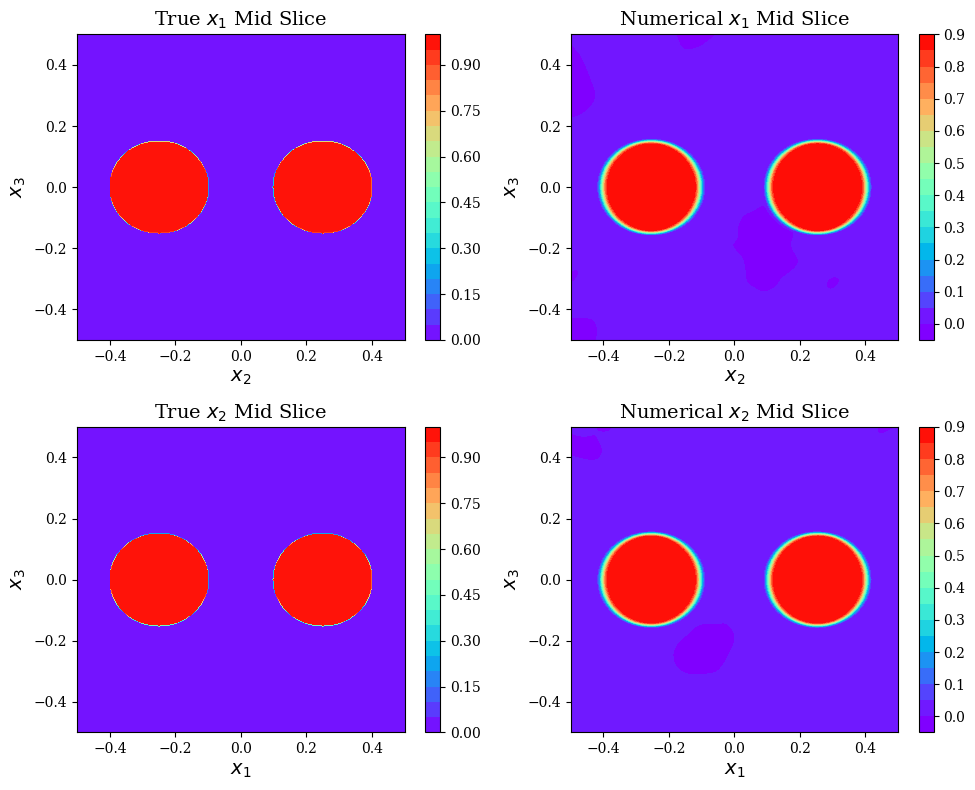

candidate idx=8, lamb=1.0, S_l_inf=2.191860119806547, S_l_2=0.2033658831953482
picked idx: 6
lamb: 0.010000000000000002


In [24]:
reload(inverse_solver)
reload(error_general_3d)
ratio_eval = globals().get("ratio1", [0.5, 0.5, 0.5])
window_idx, window_lambda, window_w, curvature = inverse_solver.lambda_window_by_curvature(
    lamb_regu, res, reg_norm, radius=1, w_store=w_store
)
print('candidate idx:', window_idx)
print('candidate lambda:', window_lambda)
window_results = []
for local_i, cand_idx in enumerate(window_idx):
    cand_lamb = window_lambda[local_i]**2
    cand_w = window_w[:, local_i]
    result_tuple = error_general_3d.test(models0,model_sigmoid,sample_s,cand_w,"mix","sweet",True,False,tau_x_min,tau_x_max,tau_y_min,tau_y_max,tau_z_min,tau_z_max,center_true,R_true,r_true,1,ana_S,1,ratio_eval,device)
    window_results.append({
        'idx': int(cand_idx),
        'lambda': cand_lamb,
        'w': cand_w,
        'result': result_tuple,
    })
    print(
        f"candidate idx={int(cand_idx)}, lamb={cand_lamb}, "
        f"S_l_inf={result_tuple[2]}, S_l_2={result_tuple[3]}"
    )
pick = 0
picked = window_results[pick]
idx = picked['idx']
lamb = picked['lambda']
picked_w = picked['w']
S_num,S_true,S_l_inf,S_l_2,g_S=picked['result']
print('picked idx:', idx)
print('lamb:', lamb)



In [25]:
np.save("./noise=5%/w_store.npy",w_store)
np.save("./noise=5%/g_S1.npy",g_S)

In [27]:
torch.save(models0, "./noise=5%/model_tanh.pth")
torch.save(model_sigmoid, f"./noise=5%/model_sigmoid_{lamb}.pth")  

PicklingError: Can't pickle <class 'net_3d.local_rep'>: it's not the same object as net_3d.local_rep

In [ ]:
np.save("./noise=5%/S_num.npy",S_num)
np.save("./noise=5%/w_store.npy",w_store)
np.save("./noise=5%/sum_mat.npy",sum_mat)

In [28]:
n_integral=len(cells_store[-1])*27
print('n_integral:',n_integral)
print('center:',center)
print('r_inner:',r_inner)
print('R:',R)
print('lamb_regu:',lamb)
print('S_l21:',S_l_2)

n_integral: 38016
center: [-6.72640382e-05 -2.68422939e-03  1.52855436e-03]
r_inner: 0.14893695031995463
R: 0.25353792989701
lamb_regu: 0.010000000000000002
S_l21: 0.15406324875949587


In [ ]:
len(cells_store[-1])*27

38016